# 06 — Performance & scale-up: Python vs. Numba vs. C++, then mapping a region

Two questions, one notebook.

**Part A — the three engines (§1–2).** The solver march exists in three forms that implement the *identical* algorithm: an interpreted **generic Python** loop, the production **Numba** (`@njit`) kernel, and a standalone **C++** port (`cpp/solver.cpp`). We run all three on the same inputs, confirm they agree to double-precision round-off, and **illustrate the speed difference** — the thing you actually feel when the code runs.

**Part B — scaling to a map (§3–7).** One borehole is one solve; a *map* is thousands. We time one pixel, price the naive “solve-every-pixel” map across the three engines, then exploit the latitude symmetry that global values buy, drape the result on the real lunar surface, and finish at the poles.

> How a “C++ notebook” works: Python stays the **driver** — it serialises the inputs to one binary blob, launches the compiled executable with `subprocess`, and reads the temperature field back. The C++ file has no Python inside it; the notebook orchestrates it.

In [1]:
# --- setup: repo root, the Python<->C++ harness, and global-value physics ----
import sys, json, time, tempfile, pathlib, functools
import numpy as np, matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.image import imread
from matplotlib.colors import LightSource, Normalize

from lunar._bootstrap import find_repo_root
CODE = find_repo_root()                       # .../Lunar-Clean/code
REPO = CODE.parent                            # repo root (holds figures/, aogs/)
sys.path.insert(0, str(CODE / "pipeline" / "compute"))
import benchmark_cpp as bc                     # dump_inputs / run_cpp / run_py (reused, not duplicated)

from lunar.config import HAYNE, GRID, DT_STEP, SITES
from lunar.constants import Q_B_EQUATORIAL
from lunar.grid import make_geometric_grid
from lunar.solver import (solve_pixel, PixelInputs, standard_insolation,
                          periodic_time_grid)
from lunar.plotting import style               # applies the house rcParams
from lunar.plotting.style import (fmt_axis, C_A15, C_TEAL, C_FOREST, C_CHAR,
                                  C_DIM, C_GRID)
plt.rcParams.update({"figure.dpi": 82, "savefig.dpi": 82})   # lean inline PNGs

g   = make_geometric_grid(**GRID)
t   = periodic_time_grid(DT_STEP)
n_t = t.size

# GLOBAL values (no per-site retrieval) -- used by the mapping half (part B)
Ks, H, chi = HAYNE["K_S"], HAYNE["H"], HAYNE["CHI"]
Kd_global  = 0.0034
albedo     = float(np.mean([SITES[s]["albedo"] for s in ("A15", "A17")]))
Q_b        = Q_B_EQUATORIAL

print(f"grid: {g.z_mid.size} cells to {g.z_mid[-1]:.1f} m, {n_t} steps/lunation")
print(f"global values -> K_d={Kd_global*1e3:.1f} mW/m/K, albedo={albedo:.3f}, "
      f"Q_b={Q_b*1e3:.0f} mW/m^2")
print(f"repo: {REPO}")


grid: 69 cells to 4.8 m, 1417 steps/lunation
global values -> K_d=3.4 mW/m/K, albedo=0.134, Q_b=18 mW/m^2
repo: /Users/rp3gregorio/Developer/Lunar-Clean


## 1. Three engines, one algorithm — and they agree

`cpp/solver.cpp` reimplements the compiled Python kernel (`solver._march_radiative_hayne`) line-for-line: Crank–Nicolson step, midpoint-Picard property sweeps, Newton surface balance, Thomas solve, and the cycle-closing wrap step — same equations, same order of operations. First we compile it, then we run all three engines on identical inputs and demand they match.

In [2]:
# rebuild the C++ binary if solver.cpp changed since the last compile
import subprocess
src, binp = CODE/"cpp"/"solver.cpp", CODE/"cpp"/"lunar_solver"
if not binp.exists() or src.stat().st_mtime > binp.stat().st_mtime:
    print("compiling:", " ".join(["clang++","-O3","-std=c++17","-o",binp.name,src.name]))
    subprocess.run(["clang++","-O3","-std=c++17","-o",str(binp),str(src)], check=True)
print("C++ binary ready:", binp.relative_to(REPO))


C++ binary ready: code/cpp/lunar_solver


In [3]:
# run ALL THREE engines on identical inputs and check they agree to round-off
site   = SITES["A15"]
N_LUN  = 5
insol  = standard_insolation(site["lat"], t)
T_init = np.full(g.z_mid.size, site["T_MEAN_EFF"])

with tempfile.TemporaryDirectory() as td:
    inp, outp = pathlib.Path(td)/"in.bin", pathlib.Path(td)/"out.bin"
    bc.dump_inputs(inp, g, t, insol, T_init, site, N_LUN)
    s_cpp,  T_cpp  = bc.run_cpp(inp, outp, g.z_mid.size, t.size)     # C++ port
s_njit, T_njit = bc.run_py(g, t, insol, T_init, site, N_LUN, fast=True)   # Numba kernel
s_gen,  T_gen  = bc.run_py(g, t, insol, T_init, site, N_LUN, fast=False)  # generic interpreted

d_nc = np.max(np.abs(T_njit - T_cpp))
d_gc = np.max(np.abs(T_gen  - T_cpp))
print(f"max |T_Numba   - T_C++| = {d_nc:.2e} K")
print(f"max |T_generic - T_C++| = {d_gc:.2e} K")
print("=> all three are the SAME algorithm; they agree to double-precision round-off"
      if max(d_nc, d_gc) < 1e-9 else "DIVERGED -- investigate before trusting either!")


max |T_Numba   - T_C++| = 1.17e-12 K
max |T_generic - T_C++| = 6.82e-13 K
=> all three are the SAME algorithm; they agree to double-precision round-off


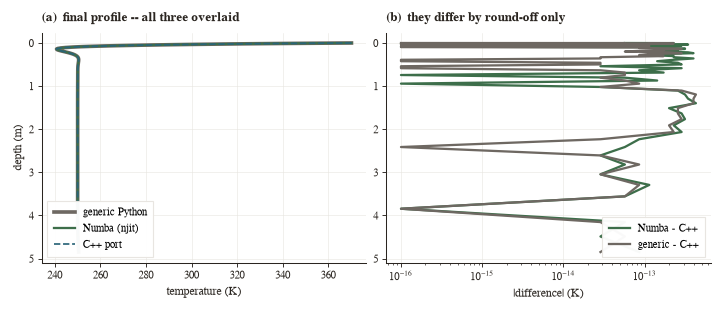

In [4]:
# see the agreement: the final-time profile from each engine, and their difference
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.6), constrained_layout=True)
a1.plot(T_gen[:, -1],  g.z_mid, "-",  color=C_DIM,  lw=3.2, label="generic Python")
a1.plot(T_njit[:, -1], g.z_mid, "-",  color=C_A15,  lw=2.0, label="Numba (njit)")
a1.plot(T_cpp[:, -1],  g.z_mid, "--", color=C_TEAL, lw=1.5, label="C++ port")
a1.invert_yaxis()
fmt_axis(a1, xlabel="temperature (K)", ylabel="depth (m)",
         title="(a)  final profile -- all three overlaid")
a1.legend(frameon=True, edgecolor=C_GRID, loc="lower left")
a2.semilogx(np.abs(T_njit[:, -1] - T_cpp[:, -1]) + 1e-16, g.z_mid, color=C_A15, label="Numba - C++")
a2.semilogx(np.abs(T_gen[:, -1]  - T_cpp[:, -1]) + 1e-16, g.z_mid, color=C_DIM, label="generic - C++")
a2.invert_yaxis()
fmt_axis(a2, xlabel="|difference| (K)", title="(b)  they differ by round-off only")
a2.legend(frameon=True, edgecolor=C_GRID, loc="lower right")
plt.show()


## 2. The speed difference — generic Python vs. Numba vs. C++

Same answer, wildly different cost. The fair way to compare is **steady-state ms per lunation** (many lunations, so Numba’s one-time JIT compile is amortised) — archived in `results/cpp_benchmark.json`. Panel (a) spans the two decades from interpreted Python to compiled code; panel (b) zooms in on the two compiled engines, which sit within ~1.5× of each other because they compile the *same* kernel to machine code.

solver march, steady-state ms per lunation (results/cpp_benchmark.json):
  generic Python     485.86 ms/lun    x   1.0 vs generic Python
  Numba (njit)         4.38 ms/lun    x 110.9 vs generic Python
  C++ port             2.99 ms/lun    x 162.4 vs generic Python

  C++ is x1.46 the Numba rate -- same order, because both compile the SAME kernel to machine code.


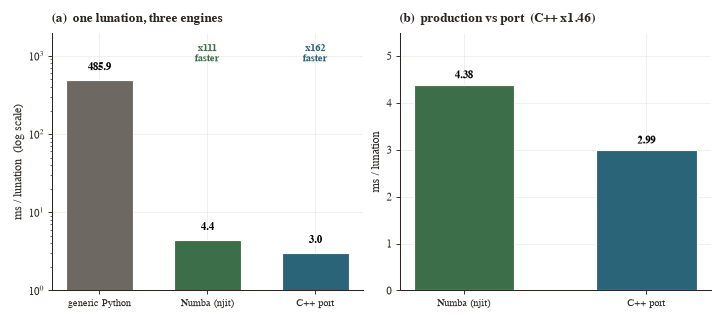

In [5]:
# --- the speed difference, illustrated -----------------------------------------
# Fair steady-state rates come from results/cpp_benchmark.json (50 lunations,
# median of 3, so Numba's one-time ~0.2 s JIT-compile is fully amortised).
bench = json.loads((CODE/"results"/"cpp_benchmark.json").read_text())
rows = [("generic Python", bench["py_ms_per_lunation"],      C_DIM),
        ("Numba (njit)",    bench["py_njit_ms_per_lunation"], C_A15),
        ("C++ port",        bench["cpp_ms_per_lunation"],     C_TEAL)]
labels, vals, cols = [r[0] for r in rows], [r[1] for r in rows], [r[2] for r in rows]
base = vals[0]
print("solver march, steady-state ms per lunation (results/cpp_benchmark.json):")
for lab, v, _ in rows:
    print(f"  {lab:16s} {v:8.2f} ms/lun    x{base/v:6.1f} vs generic Python")
print(f"\n  C++ is x{vals[1]/vals[2]:.2f} the Numba rate -- same order, "
      f"because both compile the SAME kernel to machine code.")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.6, 3.7), constrained_layout=True)
# (a) all three, log scale (spans two decades)
bars = a1.bar(range(3), vals, color=cols, width=0.62, edgecolor="white", zorder=3)
a1.set_yscale("log"); a1.set_xticks(range(3)); a1.set_xticklabels(labels, fontsize=9)
a1.set_ylim(1, base*4)
for i, v in enumerate(vals):
    a1.text(i, v*1.25, f"{v:.1f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
for i in (1, 2):
    a1.text(i, base*2.2, f"x{base/vals[i]:.0f}\nfaster", ha="center", va="center",
            fontsize=9, color=cols[i], fontweight="bold")
fmt_axis(a1, ylabel="ms / lunation  (log scale)", title="(a)  one lunation, three engines")
# (b) Numba vs C++, zoomed linear -- they are close
a2.bar([0, 1], vals[1:], color=cols[1:], width=0.55, edgecolor="white", zorder=3)
a2.set_xticks([0, 1]); a2.set_xticklabels(["Numba (njit)", "C++ port"], fontsize=9)
a2.set_ylim(0, max(vals[1:])*1.25)
for i, v in enumerate(vals[1:]):
    a2.text(i, v+0.08, f"{v:.2f}", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
fmt_axis(a2, ylabel="ms / lunation",
         title=f"(b)  production vs port  (C++ x{vals[1]/vals[2]:.2f})")
plt.show()


## 3. Scaling to a map — one pixel, timed

`solve_pixel` marches the radiative surface energy balance to a converged periodic cycle and returns the skin-temperature history. Warm up Numba (the first call compiles), then time one equatorial pixel — the unit cost of a map.

In [6]:
def one_solve(lat_deg):
    insol = standard_insolation(lat_deg, t)
    out = solve_pixel(PixelInputs(
        grid=g, t=t, bc_mode='radiative', insolation=insol, albedo=albedo,
        emissivity=0.95, Q_b=Q_b, n_lunations_spinup=80, spinup_tol_K=0.05,
        spinup_depth_m=0.15, hayne_params=(Ks, Kd_global, H, chi)))
    return out.T_surface

_ = one_solve(0.0)
t0 = time.perf_counter(); T0 = one_solve(0.0); t_solve = time.perf_counter() - t0
print(f'one equatorial pixel, Numba solver: {t_solve:.3f} s')
print(f'  diurnal swing: night {T0.min():.0f} K  ->  noon {T0.max():.0f} K')

one equatorial pixel, Numba solver: 0.200 s
  diurnal swing: night 96 K  ->  noon 384 K


## 4. The naive process — solve every pixel

A map is a grid of pixels; the naive method solves each one. We scale the measured Numba time by the **real** backend ratios from `results/cpp_benchmark.json` (§2) and extrapolate to a full 1°-resolution Moon.

In [7]:
lat_grid = np.arange(-75, 76, 3.0)                     # 51 rows
lon_grid = np.arange(-90, 91, 3.0)                     # 61 cols
n_region = lat_grid.size * lon_grid.size
n_full   = 181 * 361

bench = json.loads((CODE / 'results' / 'cpp_benchmark.json').read_text())
r_py  = bench['py_ms_per_lunation']  / bench['py_njit_ms_per_lunation']
r_cpp = bench['cpp_ms_per_lunation'] / bench['py_njit_ms_per_lunation']

def fmt(s):
    return f'{s:5.1f} s' if s < 90 else (f'{s/60:5.1f} min' if s < 5400 else f'{s/3600:5.1f} h')

print(f'Region: {lat_grid.size} lat x {lon_grid.size} lon = {n_region} pixels '
      f'(global values)\n')
print(f'{"backend":<15}{"per pixel":>11}{"this region":>13}{"full 1-deg Moon":>17}')
print('-' * 56)
for name, per in [('pure Python', t_solve * r_py),
                  ('Numba (njit)', t_solve),
                  ('C++ port', t_solve * r_cpp)]:
    print(f'{name:<15}{per:>9.3f} s{fmt(per*n_region):>13}{fmt(per*n_full):>17}')

Region: 51 lat x 61 lon = 3111 pixels (global values)

backend          per pixel  this region  full 1-deg Moon
--------------------------------------------------------
pure Python       22.124 s       19.1 h          401.5 h
Numba (njit)       0.200 s     10.3 min            3.6 h
C++ port           0.136 s      7.1 min            2.5 h


## 5. The smart process — exploit the latitude symmetry

With **global values** a pixel’s diurnal cycle depends only on its **latitude** — longitude just sets the clock. Solve each unique latitude **once**, then read the map off by local solar time. This is the collapse from *N* pixels to a handful of solves.

In [8]:
uniq = np.unique(np.abs(lat_grid))
t1 = time.perf_counter()
field = {la: one_solve(float(la)) for la in uniq}
t_smart = time.perf_counter() - t1
print(f'solved {uniq.size} unique latitudes in {t_smart:.1f} s '
      f'-> {n_region/uniq.size:.0f}x fewer solves than the naive {n_region}')

def region_map(sslon=0.0):
    M = np.empty((lat_grid.size, lon_grid.size))
    for i, la in enumerate(lat_grid):
        idx = (((lon_grid - sslon) % 360) / 360 * n_t).astype(int) % n_t
        M[i] = field[abs(la)][idx]
    return M

Tmap = region_map(0.0)
print(f'map temperature range: {Tmap.min():.0f} - {Tmap.max():.0f} K')

# vectorised T(lat, hour-angle) for smooth fine-resolution rendering
ladder = np.array(sorted(field)); FIELD = np.array([field[la] for la in ladder])
def T_at(lat, hourangle):
    lat = np.abs(lat); frac = (hourangle % 360) / 360; ti = frac * n_t
    i0 = np.floor(ti).astype(int) % n_t; i1 = (i0 + 1) % n_t; w = ti - np.floor(ti)
    li = np.interp(lat, ladder, np.arange(ladder.size))
    l0 = np.floor(li).astype(int); l1 = np.minimum(l0 + 1, ladder.size - 1); wl = li - l0
    g0 = (1 - w) * FIELD[l0, i0] + w * FIELD[l0, i1]
    g1 = (1 - w) * FIELD[l1, i0] + w * FIELD[l1, i1]
    return (1 - wl) * g0 + wl * g1

solved 26 unique latitudes in 5.8 s -> 120x fewer solves than the naive 3111
map temperature range: 80 - 384 K


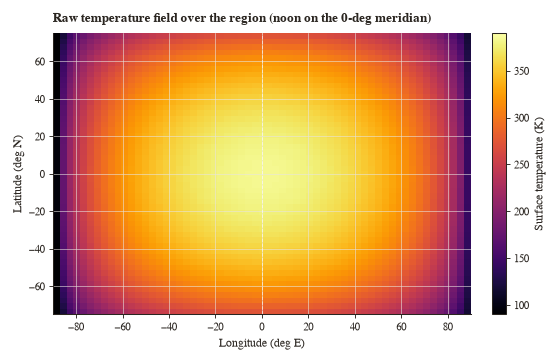

In [9]:
ext = [lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()]
fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)
pc = ax.imshow(Tmap, extent=ext, origin='lower', aspect='auto',
               cmap='inferno', vmin=90, vmax=390)
fig.colorbar(pc, ax=ax).set_label('Surface temperature (K)')
ax.axvline(0, color='w', lw=0.8, ls='--', alpha=0.6)
fmt_axis(ax, xlabel='Longitude (deg E)', ylabel='Latitude (deg N)',
         title='Raw temperature field over the region (noon on the 0-deg meridian)')
plt.show()

## 6. Drape it on the real surface

The smooth field says *what* the temperature is, not *where*. We drape it on the real lunar surface — the Clementine albedo mosaic × LOLA shaded relief — so craters and maria show through (temperature colour × relief shading). Nothing is re-solved.

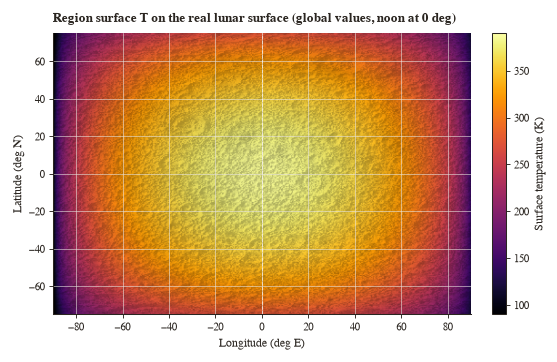

In [10]:
# --- real-surface basemap: Clementine albedo x LOLA hillshade -------------
ALB = CODE.parent / 'figures' / 'moon_global.png'
DEM = CODE.parent / 'aogs' / 'data' / 'lola' / 'ldem_16.img'

def _load_relief():
    alb = imread(str(ALB)); alb = alb[..., :3].mean(-1) if alb.ndim == 3 else alb
    Hn, Wn = alb.shape
    if DEM.exists():
        dem = np.fromfile(DEM, dtype='<i2').reshape(2880, 5760).astype(float) * 0.5
        fy, fx = 2880 // Hn, 5760 // Wn
        dem = dem[:fy*Hn:fy, :fx*Wn:fx][:Hn, :Wn]
        hs = LightSource(azdeg=300, altdeg=42).hillshade(dem, vert_exag=90, dx=1, dy=1)
    else:
        hs = np.full_like(alb, 0.6)
    base = 0.45 * (alb / max(alb.max(), 1e-6)) + 0.55 * hs
    return np.clip(0.35 + 0.75 * (base - base.min()) / (np.ptp(base) + 1e-9), 0, 1)

RELIEF = _load_relief(); Hn, Wn = RELIEF.shape

def relief_at(lat, lon):
    r = np.clip(((90 - lat) / 180 * (Hn - 1)).astype(int), 0, Hn - 1)
    c = np.clip(((lon + 180) / 360 * (Wn - 1)).astype(int), 0, Wn - 1)
    return RELIEF[r, c]

def drape(T2d, lat2d, lon2d):
    '''temperature colour x relief shading -> RGB (craters show through).'''
    col = cm.inferno((np.clip(T2d, 90, 390) - 90) / 300)[..., :3]
    shade = 0.42 + 0.58 * relief_at(lat2d, lon2d)
    return np.clip(col * shade[..., None], 0, 1)

# fine render grid (smooth temperature x fine relief -> visible craters)
FLA, FLO = np.meshgrid(np.linspace(lat_grid.min(), lat_grid.max(), 300),
                       np.linspace(lon_grid.min(), lon_grid.max(), 460), indexing='ij')
def region_rgb(sslon=0.0):
    return drape(T_at(FLA, FLO - sslon), FLA, FLO)

sm = cm.ScalarMappable(norm=Normalize(90, 390), cmap='inferno')
fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)
ax.imshow(region_rgb(0.0), extent=ext, origin='lower', aspect='auto', interpolation='bilinear')
ax.axvline(0, color='w', lw=0.8, ls='--', alpha=0.6)
fig.colorbar(sm, ax=ax).set_label('Surface temperature (K)')
fmt_axis(ax, xlabel='Longitude (deg E)', ylabel='Latitude (deg N)',
         title='Region surface T on the real lunar surface (global values, noon at 0 deg)')
plt.show()

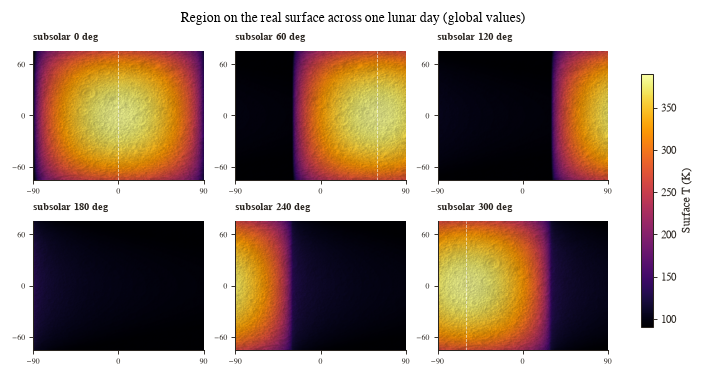

wrote figures/anim/lunar_region_daycycle.gif  (2.6 MB)


In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter
ANIM = CODE.parent / 'figures' / 'anim'; ANIM.mkdir(parents=True, exist_ok=True)

figF, axes = plt.subplots(2, 3, figsize=(8.4, 4.4), constrained_layout=True)
for ax, ss in zip(axes.ravel(), [0, 60, 120, 180, 240, 300]):
    ax.imshow(region_rgb(ss), extent=ext, origin='lower', aspect='auto', interpolation='bilinear')
    ax.axvline(((ss + 180) % 360) - 180, color='w', lw=0.7, ls='--', alpha=0.7)
    ax.set_title(f'subsolar {ss:.0f} deg', fontsize=9)
    ax.set_xticks([-90, 0, 90]); ax.set_yticks([-60, 0, 60])
    ax.tick_params(labelsize=7); ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
figF.colorbar(sm, ax=axes, shrink=0.85, label='Surface T (K)')
figF.suptitle('Region on the real surface across one lunar day (global values)')
plt.show()

figA, axA = plt.subplots(figsize=(5.2, 3.5))
imA = axA.imshow(region_rgb(0.0), extent=ext, origin='lower', aspect='auto', interpolation='bilinear')
ln = axA.axvline(0, color='w', lw=0.9, ls='--', alpha=0.7)
figA.colorbar(sm, ax=axA).set_label('Surface T (K)')
axA.set_xlabel('Longitude (deg E)'); axA.set_ylabel('Latitude (deg N)')
axA.set_xlim(ext[0], ext[1]); axA.set_ylim(ext[2], ext[3])
tt = axA.set_title(''); figA.tight_layout()
NF = 60
def _upd(f):
    ss = 360 * f / NF
    imA.set_data(region_rgb(ss))
    ln.set_xdata([((ss + 180) % 360) - 180] * 2)
    tt.set_text(f'Region surface T on the real surface -- subsolar {ss:.0f} deg')
    return [imA]
gif = ANIM / 'lunar_region_daycycle.gif'
FuncAnimation(figA, _upd, frames=NF, interval=70, blit=False).save(
    str(gif), writer=PillowWriter(fps=14), dpi=90)
plt.close(figA)
try:
    from PIL import Image, ImageSequence
    im = Image.open(gif)
    fr = [f.convert('RGB').quantize(colors=96) for f in ImageSequence.Iterator(im)]
    fr[0].save(gif, save_all=True, append_images=fr[1:], loop=0, duration=70, optimize=True)
except Exception as e:
    print('optimize skipped:', e)
print(f'wrote {gif.relative_to(CODE.parent)}  ({gif.stat().st_size/1e6:.1f} MB)')

The animation is saved to `figures/anim/lunar_region_daycycle.gif` and plays in Jupyter — the dashed line is local noon sweeping the region:

![Region surface temperature across one lunar day](../../figures/anim/lunar_region_daycycle.gif)

## 7. The polar regions

The equatorial band never gets cold at noon; the **poles** are the opposite. With the Sun always near the horizon (grazing incidence) they stay cold through the whole lunar day. We extend the latitude ladder to the pole and project each pole to a top-down disk, on the same LOLA relief.

North cap: coldest 59 K at the pole, warmest 333 K at the sunlit rim
South cap: coldest 59 K at the pole, warmest 333 K at the sunlit rim


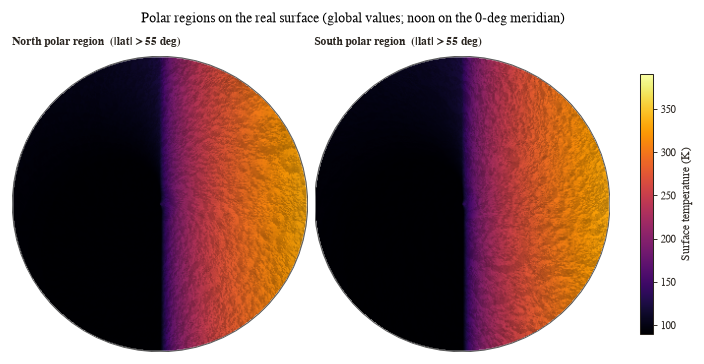

In [12]:
# extend the latitude ladder to the pole; T_at picks up the new FIELD
for la in [60., 65., 70., 75., 80., 85., 89.]:
    field.setdefault(la, one_solve(la))
ladder = np.array(sorted(field)); FIELD = np.array([field[la] for la in ladder])

def polar_rgba(pole, sslon=0.0, npx=300, lat_min=55.0):
    lin = np.linspace(-1, 1, npx); X, Y = np.meshgrid(lin, lin)
    r = np.hypot(X, Y); mask = r <= 1
    colat = r * (90 - lat_min)
    lat = (90 - colat) if pole == 'N' else -(90 - colat)
    lon = np.degrees(np.arctan2(Y, X))
    T = T_at(lat, lon - sslon)
    rgba = np.dstack([drape(T, lat, lon), mask.astype(float)])
    return rgba, np.where(mask, T, np.nan)

figP, (axN, axS) = plt.subplots(1, 2, figsize=(8.4, 4.4), constrained_layout=True)
for axp, pole, nm in [(axN, 'N', 'North'), (axS, 'S', 'South')]:
    rgba, T = polar_rgba(pole, sslon=0.0)
    axp.imshow(rgba, extent=[-1, 1, -1, 1], origin='lower', interpolation='bilinear')
    axp.add_patch(plt.Circle((0, 0), 1, fill=False, ec='0.35', lw=0.9))
    axp.set_aspect('equal'); axp.axis('off')
    axp.set_title(f'{nm} polar region  (|lat| > 55 deg)', fontsize=10)
    print(f'{nm} cap: coldest {np.nanmin(T):.0f} K at the pole, '
          f'warmest {np.nanmax(T):.0f} K at the sunlit rim')
figP.colorbar(sm, ax=[axN, axS], shrink=0.8, label='Surface temperature (K)')
figP.suptitle('Polar regions on the real surface (global values; noon on the 0-deg meridian)')
plt.show()

## Takeaways

- **One algorithm, three engines.** The generic Python `_step` loop, the
  production **Numba** kernel, and the **C++** port implement the *same*
  Crank–Nicolson march and agree to ~$10^{-12}$ K. That is what lets the C++
  port stand as an independent cross-check of the science code.
- **Numba buys ~100× over interpreted Python; C++ adds only ~1.3–1.5× on top.**
  So the production path is Numba (no build step, no second language), and C++
  is kept as the correctness witness — not because it is meaningfully faster.
- **The solver is the bottleneck of any map.** A map is *N* independent solves.
  Pure Python would take **~20 days** for a full 1° Moon; Numba and C++ both do
  it in **hours**.
- **Global values → a 1-D problem.** Uniform properties make the cycle depend
  only on latitude, collapsing *N* pixels to a handful of unique latitudes. Make
  the properties **per-pixel** (local albedo, slope, or a retrieved per-site
  $K_d$) and that symmetry breaks — back to the full *N*-solve cost, which is
  exactly when the fast solver earns its keep.
- **Geography matters at the poles.** With the Sun forever near the horizon the
  poles stay cold through the whole lunar day — the regime that makes lunar cold
  traps possible.


## 📎 Code this notebook uses
*(full map of every notebook → [`README.md`](README.md))*

- **Engine — `src/lunar/`:** `config`, `constants`, `grid`, `solver`, `plotting`, `_bootstrap`
- **Compute — `pipeline/compute/`:** `benchmark_cpp` (builds + runs `cpp/solver.cpp`, checks it matches the Python solver)
- **C++ — `cpp/solver.cpp`:** the standalone 300-line port (plain C++17, zero deps)
- **Data — `results/`:** `cpp_benchmark.json` (fair Python / Numba / C++ timings)
- **Surface texture:** `figures/moon_global.png` (Clementine albedo, USGS/NASA), `aogs/data/lola/ldem_16.img` (LOLA relief)

> **Two languages, one truth.** Any change to the physics march must land in
> *both* `lunar/solver.py` (Numba kernel) and `cpp/solver.cpp`, then this
> notebook (or `devcheck cpp`) must show the ~$10^{-12}$ K agreement before
> either is trusted.
